In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sqlite3

In [2]:
# connecting to SQlite database
con = sqlite3.connect(r"C:\Users\Administrator\Downloads\password_resources\password_data.sqlite")

In [3]:
# extracts the data
data = pd.read_sql_query("SELECT * FROM Users", con)

In [4]:
data.shape

(100000, 3)

In [5]:
data.head()

,index,password,strength
0,0,zxe870819,1
1,1,xw46454nr23l,1
2,2,soporte13,1
3,3,accounts6000webhost.com,2
4,4,c443balg,1


# Data Cleaning

In [6]:
# finds number of missing values per column
data.isna().sum()

index       0
password    0
strength    0
dtype: int64

In [7]:
# Dropping index column as it is redundant
data.drop(['index'], axis = 1, inplace = True)

In [8]:
data.head()

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
3,accounts6000webhost.com,2
4,c443balg,1


In [9]:
data.duplicated().sum()

0

In [10]:
data["strength"].unique()

array([1, 2, 0], dtype=int64)

# Data Analysis (Semantic analysis)

## Finding number of passwords in each of the categories (Numeric, Upper Case, Alphabetical, Alphanumeric)

In [11]:
data["password"].str.isnumeric()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: password, Length: 100000, dtype: bool

In [15]:
data[data["password"].str.isnumeric()]

,password,strength
12280,943801,0
14992,12345,0
20958,147856,0
21671,140290,0
23269,123987,0
28569,1233214,0
31329,0159456,0
32574,363761,0
37855,4524344,0
43648,5521597,0


In [16]:
data[data["password"].str.isnumeric()].shape[0]

26

In [17]:
data[data["password"].str.isupper()]

,password,strength
115,EYT63119,1
273,INSPIRON6,1
338,1A2S3D4F,1
367,13269123A,1
373,YAMAZAKI82,1
...,...,...
99590,V13000993J,1
99692,65925013ABC,1
99784,01EDD055,1
99893,1UPONYOU,1


In [18]:
data[data["password"].str.isupper()].shape[0]

1506

In [19]:
data[data["password"].str.isalpha()]

,password,strength
267,PomarancaÇ,1
1380,smgodt,0
3198,cuado,0
4560,jelsz,0
6380,demsxp,0
7803,secret,0
9218,caballo,0
11555,mhe,0
11667,kreedo,0
13645,nõmlich,0


In [20]:
data[data["password"].str.isalpha()].shape[0]

50

In [21]:
data[data["password"].str.isalnum()]

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
4,c443balg,1
5,16623670p,1
...,...,...
99995,obejofi215,1
99996,fmiopvxb64,1
99997,czvrbun38,1
99998,mymyxe430,1


In [22]:
data[data["password"].str.isalnum()].shape[0]

97203

In [23]:
data[data["password"].str.istitle()]

,password,strength
64,Hisanthoshjasika0,2
242,Therockrockbottom72,2
338,1A2S3D4F,1
367,13269123A,1
526,Csicskarozsika1,2
...,...,...
99168,1053815198M,1
99192,Alfranx05122023,2
99375,Kensington1956,2
99590,V13000993J,1


In [24]:
data[data["password"].str.istitle()].shape[0]

932

Most passwords are alphanumeric (97203)

In [12]:
import string

In [13]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [14]:
# Function that filters rows containing at least one punctuation
def find_semantics(row):
    for char in row:
        if char in string.punctuation:
            return 1
        else:
            pass

In [28]:
data[data["password"].apply(find_semantics)==1]

,password,strength
3,accounts6000webhost.com,2
68,12463773800+,1
98,p.r.c.d.g.,1
145,cita-cita,1
180,karolina.susnina0U,2
...,...,...
99748,maiselis.com,1
99845,hosting4meze!@#,2
99954,semista_bakung15,2
99980,halflife2010!LEB,2


In [29]:
#Count the number of passwords containing special characters
data[data["password"].apply(find_semantics)==1].shape[0]

2663

In [15]:
# Set up conditional functions to categorize structural types
def is_numeric(pw):
    return pw.isdigit()

def is_alpha(pw):
    return pw.isalpha()

def is_alnum(pw):
    return pw.isalnum() and not pw.isdigit() and not pw.isalpha()

def has_upper(pw):
    return any(char.isupper() for char in pw)

def is_title(pw):
    return pw.istitle()

def has_special(pw):
    return any(char in string.punctuation for char in pw)

# Map each password to a unique structural string category 
data['type'] = data['password'].apply(lambda pw: 'Numeric' if is_numeric(pw)
                                     else 'Alpha' if is_alpha(pw)
                                     else 'Alphanumeric' if is_alnum(pw)
                                     else 'Uppercase' if has_upper(pw)
                                     else 'Title Case' if is_title(pw)
                                     else 'Special Characters' if has_special(pw)
                                     else 'Other')

# Compute the mean password strength for each category 
password_strength_table = data.groupby('type')['strength'].mean().reset_index()
password_strength_table.sort_values(by = "strength", ascending = False)

,type,strength
5,Uppercase,1.924731
4,Special Characters,1.402771
1,Alphanumeric,0.974291
3,Other,0.730769
0,Alpha,0.020000
2,Numeric,0.000000


# Feature engineering

In [16]:
# Adds a column that shows the length of the password
data['length'] = data['password'].str.len()

In [17]:
data.head()

,password,strength,type,length
0,zxe870819,1,Alphanumeric,9
1,xw46454nr23l,1,Alphanumeric,12
2,soporte13,1,Alphanumeric,9
3,accounts6000webhost.com,2,Special Characters,23
4,c443balg,1,Alphanumeric,8


In [18]:
# Define function to measure lowercase frequency ratio distribution proportions
def freq_lowercase(row):
    return len([char for char in row if char.islower()])/len(row)

In [19]:
# Define function to measure uppercase frequency ratio distribution proportions
def freq_uppercase(row):
    return len([char for char in row if char.isupper()])/len(row)

In [20]:
# Define function to measure numerical character frequency ratio distribution proportions
def freq_numerical_case(row):
    return len([char for char in row if char.isdigit()])/len(row)

In [21]:
data["lowercase_freq"] = np.round(data['password'].apply(freq_lowercase), 3)

data["uppercase_freq"] = np.round(data['password'].apply(freq_uppercase), 3)

data["digit_freq"] = np.round(data['password'].apply(freq_numerical_case), 3)

In [22]:
data.head()

,password,strength,type,length,lowercase_freq,uppercase_freq,digit_freq
0,zxe870819,1,Alphanumeric,9,0.333,0.0,0.667
1,xw46454nr23l,1,Alphanumeric,12,0.417,0.0,0.583
2,soporte13,1,Alphanumeric,9,0.778,0.0,0.222
3,accounts6000webhost.com,2,Special Characters,23,0.783,0.0,0.174
4,c443balg,1,Alphanumeric,8,0.625,0.0,0.375


In [23]:
# Function to retrieve counts of special character elements
def freq_special_case(row):
    special_chars = []
    for char in row:
        if not char.isalpha() and not char.isdigit():
            special_chars.append(char)
        
    return len(special_chars)

In [24]:
# Calculate and standardise special character distribution rates
data["special_freq"] = np.round(data['password'].apply(freq_special_case), 3)
data["special_freq"] = data["special_freq"] / data["length"]

In [25]:
data.head()

,password,strength,type,length,lowercase_freq,uppercase_freq,digit_freq,special_freq
0,zxe870819,1,Alphanumeric,9,0.333,0.0,0.667,0.000000
1,xw46454nr23l,1,Alphanumeric,12,0.417,0.0,0.583,0.000000
2,soporte13,1,Alphanumeric,9,0.778,0.0,0.222,0.000000
3,accounts6000webhost.com,2,Special Characters,23,0.783,0.0,0.174,0.043478
4,c443balg,1,Alphanumeric,8,0.625,0.0,0.375,0.000000


# Data Analysis p2

In [41]:
data.columns

Index(['password', 'strength', 'type', 'length', 'lowercase_freq',
       'uppercase_freq', 'digit_freq', 'special_freq'],
      dtype='object')

In [26]:
cols = ['length', 'lowercase_freq',
       'uppercase_freq', 'digit_freq', 'special_freq']
for col in cols:
    print(col)
    print(data[[col, 'strength']].groupby(['strength']).agg(['min', 'max', 'mean', 'median']))
    print('\n')

length
         length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0


lowercase_freq
         lowercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.708050  0.714
1                   0.0  0.923  0.630067  0.667
2                   0.0  0.917  0.424679  0.400


uppercase_freq
         uppercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.012872  0.000
1                   0.0  0.923  0.007915  0.000
2                   0.0  0.889  0.367633  0.429


digit_freq
         digit_freq                        
                min    max      mean median
strength                                   
0   

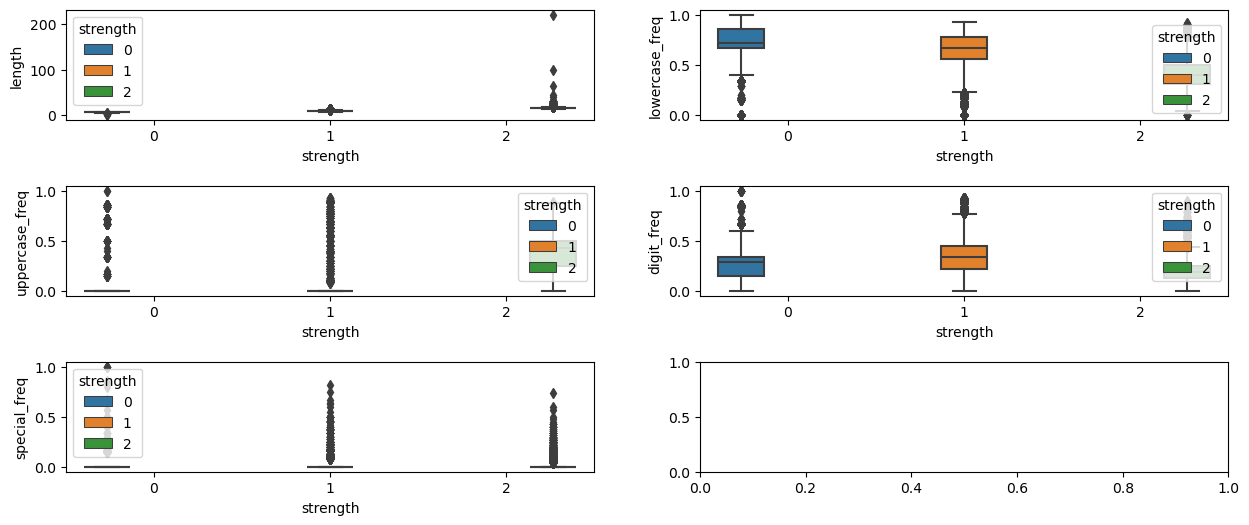

In [43]:
fig , ((ax1, ax2) , (ax3, ax4), (ax5, ax6)) = plt.subplots(3,2, figsize = (15,6))

# Plotting password strength across all frequency measures as separate boxplots
sns.boxplot(x = "strength", y = "length", hue = "strength", data = data, ax = ax1)
sns.boxplot(x = "strength", y = "lowercase_freq", hue = "strength", data = data, ax = ax2)
sns.boxplot(x = "strength", y = "uppercase_freq", hue = "strength", data = data, ax = ax3)
sns.boxplot(x = "strength", y = "digit_freq", hue = "strength", data = data, ax = ax4)
sns.boxplot(x = "strength", y = "special_freq", hue = "strength", data = data, ax = ax5)

plt.subplots_adjust(hspace = 0.6)
plt.show()

From the raw output above and the graphs, we can see higher string lengths are heavily concentrated within strength 2 and shorter string lengths tend to have a strength of 0 or 1. 

Higher strength passwords also exhibit a more balanced mix of character frequencies, special characters, uppercase characters as well as less lowercase use compared to lower strength passwords.

# Feature importance

In [44]:
data.columns

Index(['password', 'strength', 'type', 'length', 'lowercase_freq',
       'uppercase_freq', 'digit_freq', 'special_freq'],
      dtype='object')

In [27]:
# Function that plots a violinplot and a distplot (overlayed distribution)
# Each plot shows the distribution for each password strength (0,1,2)
def get_dist(data, feature):
    
    plt.figure(figsize = (10,6))
    plt.subplot(1,2,1)
    sns.violinplot(x = "strength", y = feature, data = data)

    plt.subplot(1,2,2)
    sns.distplot(data[data["strength"] == 0][feature], color = "blue", label = "0", hist = False)
    sns.distplot(data[data["strength"] == 1][feature], color = "green", label = "1", hist = False)
    sns.distplot(data[data["strength"] == 2][feature], color = "red", label = "2", hist = False)
    plt.legend()

In [28]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

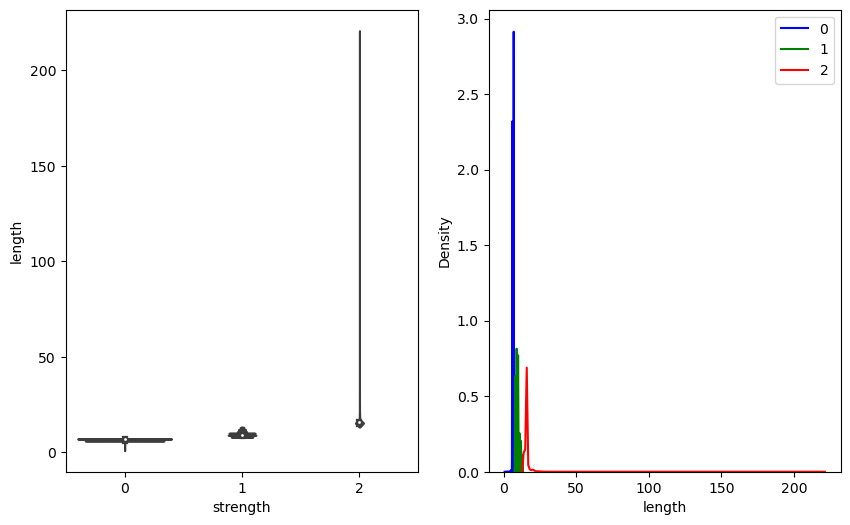

In [47]:
get_dist(data, "length")

As confirmed in the data analysis above, stronger passwords have greater length than weaker passwords

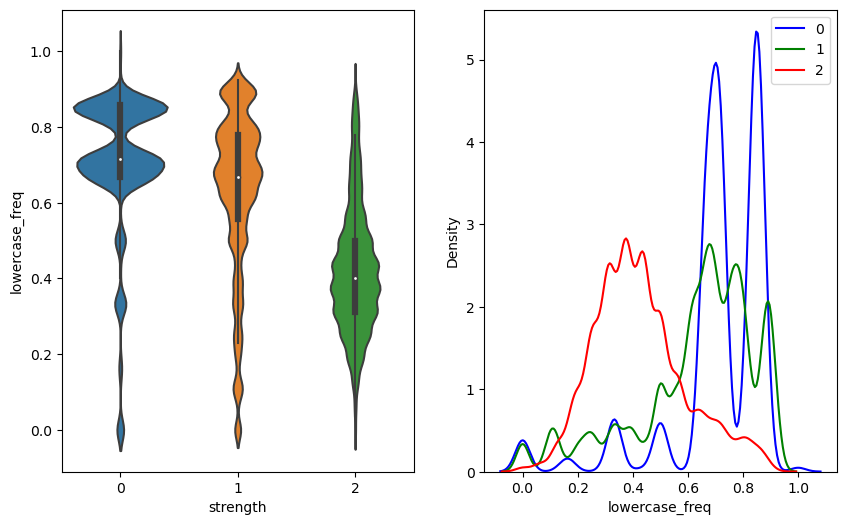

In [48]:
get_dist(data, 'lowercase_freq')

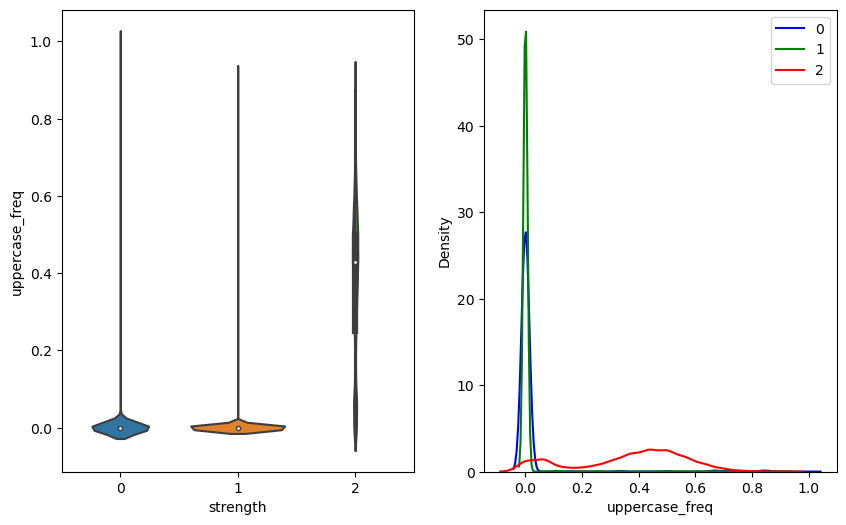

In [49]:
get_dist(data, 'uppercase_freq')

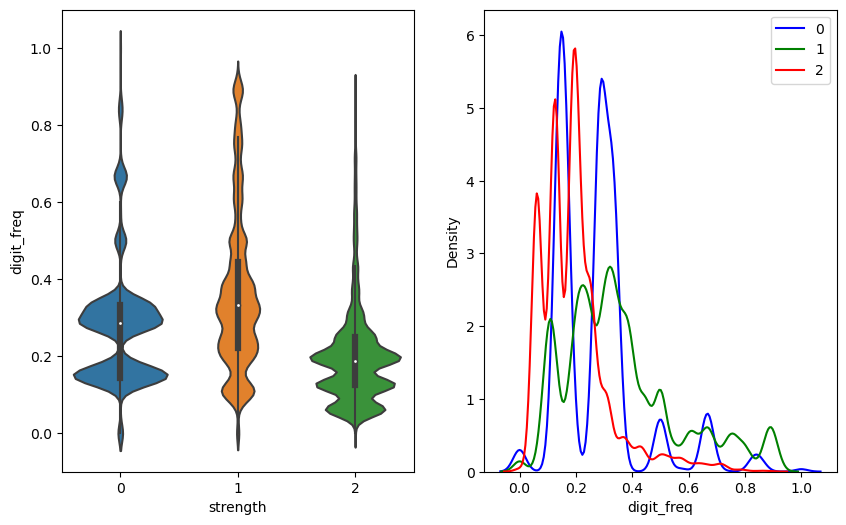

In [50]:
get_dist(data, 'digit_freq')

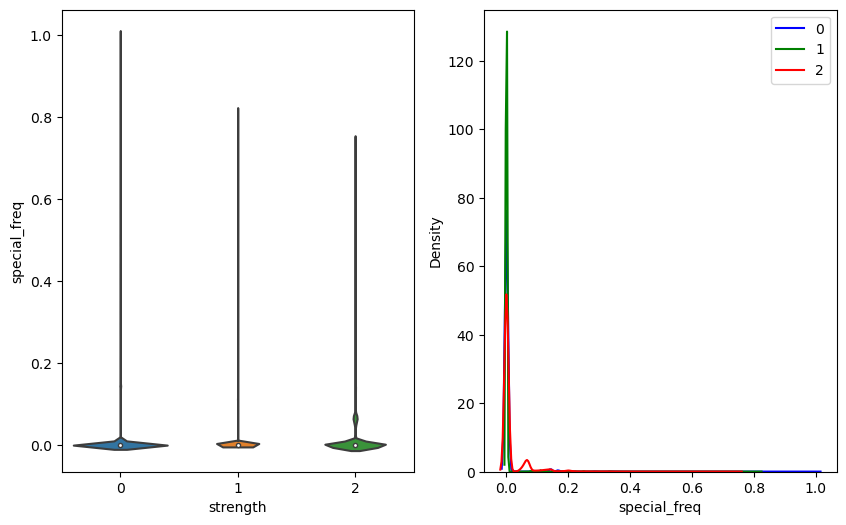

In [51]:
get_dist(data, 'special_freq')

Length and lowercase seem to be the best features (least overlapping in the distplot).

These plots also confirm our findings in the Data Analysis section, stronger passwords have greater length, more frequency of uppercase and special characters and less frequency of lowercase letters.

In [30]:
dataframe = data.sample(frac = 1)
dataframe

,password,strength,type,length,lowercase_freq,uppercase_freq,digit_freq,special_freq
78215,m3m3nto,0,Alphanumeric,7,0.714,0.000,0.286,0.0
21828,mar12onoff,1,Alphanumeric,10,0.800,0.000,0.200,0.0
6585,RHoiI0DY1NQnZ47F,2,Alphanumeric,16,0.188,0.562,0.250,0.0
38600,yanni102,1,Alphanumeric,8,0.625,0.000,0.375,0.0
31565,s5b9oTPzSIp1ASo,2,Alphanumeric,15,0.400,0.400,0.200,0.0
...,...,...,...,...,...,...,...,...
44494,zirxuokf495,1,Alphanumeric,11,0.727,0.000,0.273,0.0
44387,wn4gg22b,1,Alphanumeric,8,0.625,0.000,0.375,0.0
61213,agoh55ps,1,Alphanumeric,8,0.750,0.000,0.250,0.0
52813,yHFgNLTY0MwpR6eu,2,Alphanumeric,16,0.375,0.500,0.125,0.0


In [31]:
# creates a list of password dataframes
x = list(dataframe['password'])

In [32]:
# Library used for text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
# Initialises the vectoriser to analyse text at the character level
vectoriser = TfidfVectorizer(analyzer = "char")

In [34]:
# Learns from the list of passwords and transforms it into a matrix
X = vectoriser.fit_transform(x)

In [35]:
X.shape

(100000, 99)

In [36]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 842571 stored elements and shape (100000, 99)>

In [37]:
X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [38]:
# Checks numer of unique characters extracted by the vectoriser
len(vectoriser.get_feature_names_out())

99

In [39]:
# Converts dense array into a dataframe
df2 = pd.DataFrame(X.toarray(), columns = vectoriser.get_feature_names_out())

In [40]:
df2

,,,,,,,,,!,#,...,ñ,ó,õ,ö,÷,ú,ü,ý,þ,›
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Modelling

In [41]:
# Appends length and lowercase_freq columns from original dataframe into the new feature dataframe
df2['length'] = dataframe['length']
df2['lowercase_freq'] = dataframe['lowercase_freq']	

In [42]:
df2.head()

,,,,,,,,,!,#,...,õ,ö,÷,ú,ü,ý,þ,›,length,lowercase_freq
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.333
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,0.417
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,0.783
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0.625


In [43]:
y = dataframe['strength']

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
# Splits feature and target variable into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    df2, y, test_size = 0.2)

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
# Fits a multinomial logistic regression on the training data
log_model = LogisticRegression(multi_class = "multinomial")
# multiclass used when we have more than 2 classes, which in this case we do
log_model.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

In [48]:
# Predicting for the test data
y_pred = log_model.predict(X_test)

In [49]:
from collections import Counter

In [50]:
Counter(y_pred)

Counter({1: 17091, 2: 1638, 0: 1271})

In [51]:
Counter(y_test)

Counter({1: 14802, 0: 2708, 2: 2490})

Observing the counts of each strength category, the model predicted too many passwords as category '1' (17091 vs 14802) and predicted less category '0' (1271 vs 2708) and '2' (1638 vs 2490). It seems to have got the general pattern correct but due to the imbalance within categories, it favoured Category '1' more than required.

In [52]:
from sklearn.metrics import r2_score

In [53]:
r2_score(y_test, y_pred)

0.18258131006328826

Low R^2 indicates model cannot explain the variability within the data well. The model may be underfitting and we might need a more complex model (e.g. neural network).

## Test

In [54]:
# Defines a password upon the user's choice, converts it to an array and applies the vectoriser transformation
password = "$!&x6th78eQ"
sample_array = np.array([password])
sample_matrix = vectoriser.transform(sample_array)

In [55]:
sample_matrix.toarray().shape

(1, 99)

In [56]:
len(password)

11

In [57]:
# Extracts all lowercase characters from the sample password
[char for char in password if char.islower()]

['x', 't', 'h', 'e']

In [58]:
# Calculates proportion of lowercase characters
len([char for char in password if char.islower()]) / len(password)

0.36363636363636365

In [59]:
# Flatten and add engineered features to the dense array
np.append(sample_matrix.toarray(), (12, 0.416)).shape

(101,)

In [60]:
# Reshapes feature array back into a 2D matrix
np.append(sample_matrix.toarray(), (12, 0.416)).reshape(1,101)

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.45752641,  0.        ,
         0.49583592,  0.        ,  0.54347215,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.17415091,  0.17335784,  0.1679759 ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.12944797,  0.        ,  0.        ,  0.17834917,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.20930477,  0.        ,
         0.        ,  0.15670005,  0.        ,  0.        ,  0.        ,
         0.20959097,  0.        ,  0.        ,  0. 

In [61]:
new_matrix = np.append(sample_matrix.toarray(), (12, 0.416)).reshape(1,101)

In [62]:
log_model.predict(new_matrix)

array([0], dtype=int64)

In [63]:
# A function that automates the whole testing process, allowing users to input a password of their choice
# Performing the same operations as above, the function will output one of 3 statements depending on the strength of the password
def predict():
    password = input("Enter password : ")
    sample_array = np.array([password])
    sample_matrix = vectoriser.transform(sample_array)

    length_pass = len(password)
    length_normalised_lowercase = len([char for char in password if char.islower()]) / len(password)

    new_matrix2 = np.append(sample_matrix.toarray(), (length_pass, length_normalised_lowercase)).reshape(1,101)
    result = log_model.predict(new_matrix2)

    if result == 0:
        return "Your password is weak. Do better!"
    elif result == 1:
        return "Your password is ok, could be better though"
    else:
        return "Your password is great!"

In [64]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [65]:
accuracy_score(y_test, y_pred)

0.8013

In [66]:
confusion_matrix(y_test, y_pred)

array([[  663,  2044,     1],
       [  518, 14005,   279],
       [   90,  1042,  1358]], dtype=int64)

In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.24      0.33      2708
           1       0.82      0.95      0.88     14802
           2       0.83      0.55      0.66      2490

    accuracy                           0.80     20000
   macro avg       0.72      0.58      0.62     20000
weighted avg       0.78      0.80      0.78     20000



Even though the R^2 score was poor, the overall accuracy implies good model performance. Looking at the confusion matrix, we can see the most misclassifications occur when predicting for Class 1, as the model confuses it with Class 0 or Class 2.